# HVM MultiHeadTransformerV2 Sweep Results
Loads all `checkpoints/multihead_v2/hvm_v2/*/best.pt` and visualises performance.

Targets: **global SigLIP (1152-d)**, **obj SigLIP (1152-d)**, **CLIP-short (768-d)**.

Primary metric: **mean cosine similarity** `(cos_sg + cos_so + cos_clip) / 3`.
SigLIP heads use InfoNCE + cosine loss (`nce_weight=0.1`, fixed). CLIP head uses cosine only — 2-AFC is only reported for the two SigLIP heads.
Two category conditioning modes compared: `given` (GT label) and `predict` (internal 2-layer MLP classifier).

In [1]:
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

SWEEP_AXES = ['cat_mode', 'd_model', 'n_layers', 'shared_dim']
SWEEP_DIR  = CHECKPOINT_DIR / 'multihead_v2' / 'hvm_v2'

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted(SWEEP_DIR.glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_cos_siglip_global' in df.columns

for col in ['d_model', 'n_layers', 'shared_dim']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

SORT_BY = 'val_mean_cos'
show_cols = SWEEP_AXES + [
    'val_mean_cos', 'val_mean_2afc',
    'val_cos_siglip_global', 'val_cos_siglip_obj', 'val_cos_clip',
    'val_2afc_siglip_global', 'val_2afc_siglip_obj',
    'val_cat_acc',
]
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} runs loaded from {SWEEP_DIR}  |  test metrics present: {has_test}')
print(df[show_cols].sort_values(SORT_BY, ascending=False).to_string(index=False))

Loading:   0%|          | 0/24 [00:00<?, ?it/s]

24 runs loaded from /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2  |  test metrics present: True
cat_mode  d_model  n_layers  shared_dim  val_mean_cos  val_mean_2afc  val_cos_siglip_global  val_cos_siglip_obj  val_cos_clip  val_2afc_siglip_global  val_2afc_siglip_obj  val_cat_acc
   given       64         2         512      0.902382       0.959551               0.854023            0.869082      0.984039                0.962297             0.956804          NaN
   given      128         2         512      0.894166       0.960300               0.840935            0.858983      0.982581                0.962297             0.958302          NaN
   given      128         2         256      0.894030       0.953371               0.843237            0.857811      0.981041                0.953059             0.953683          NaN
   given       64         2         256      0.891328       0.951186               0.850967            0.860549      0.962467                0.952310     

## Best run per cat_mode

In [2]:
cols = ['cat_mode', 'd_model', 'n_layers', 'shared_dim',
        'val_mean_cos', 'val_mean_2afc',
        'val_cos_siglip_global', 'val_cos_siglip_obj', 'val_cos_clip',
        'val_2afc_siglip_global', 'val_2afc_siglip_obj',
        'val_cat_acc']
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values('val_mean_cos', ascending=False)
      .groupby('cat_mode', sort=True)
      .first()
      .reset_index()
)[available]
display(summary)

,cat_mode,d_model,n_layers,shared_dim,val_mean_cos,val_mean_2afc,val_cos_siglip_global,val_cos_siglip_obj,val_cos_clip,val_2afc_siglip_global,val_2afc_siglip_obj,val_cat_acc
0,given,64,2,512,0.902382,0.959551,0.854023,0.869082,0.984039,0.962297,0.956804,NaN
1,predict,128,4,256,0.795038,0.513608,0.847496,0.819358,0.718259,0.521223,0.505993,0.133333


## Per-head cosine similarity and 2-AFC by sweep axis
Points coloured by `cat_mode`; horizontal bars show the mean across all other hyperparameters.

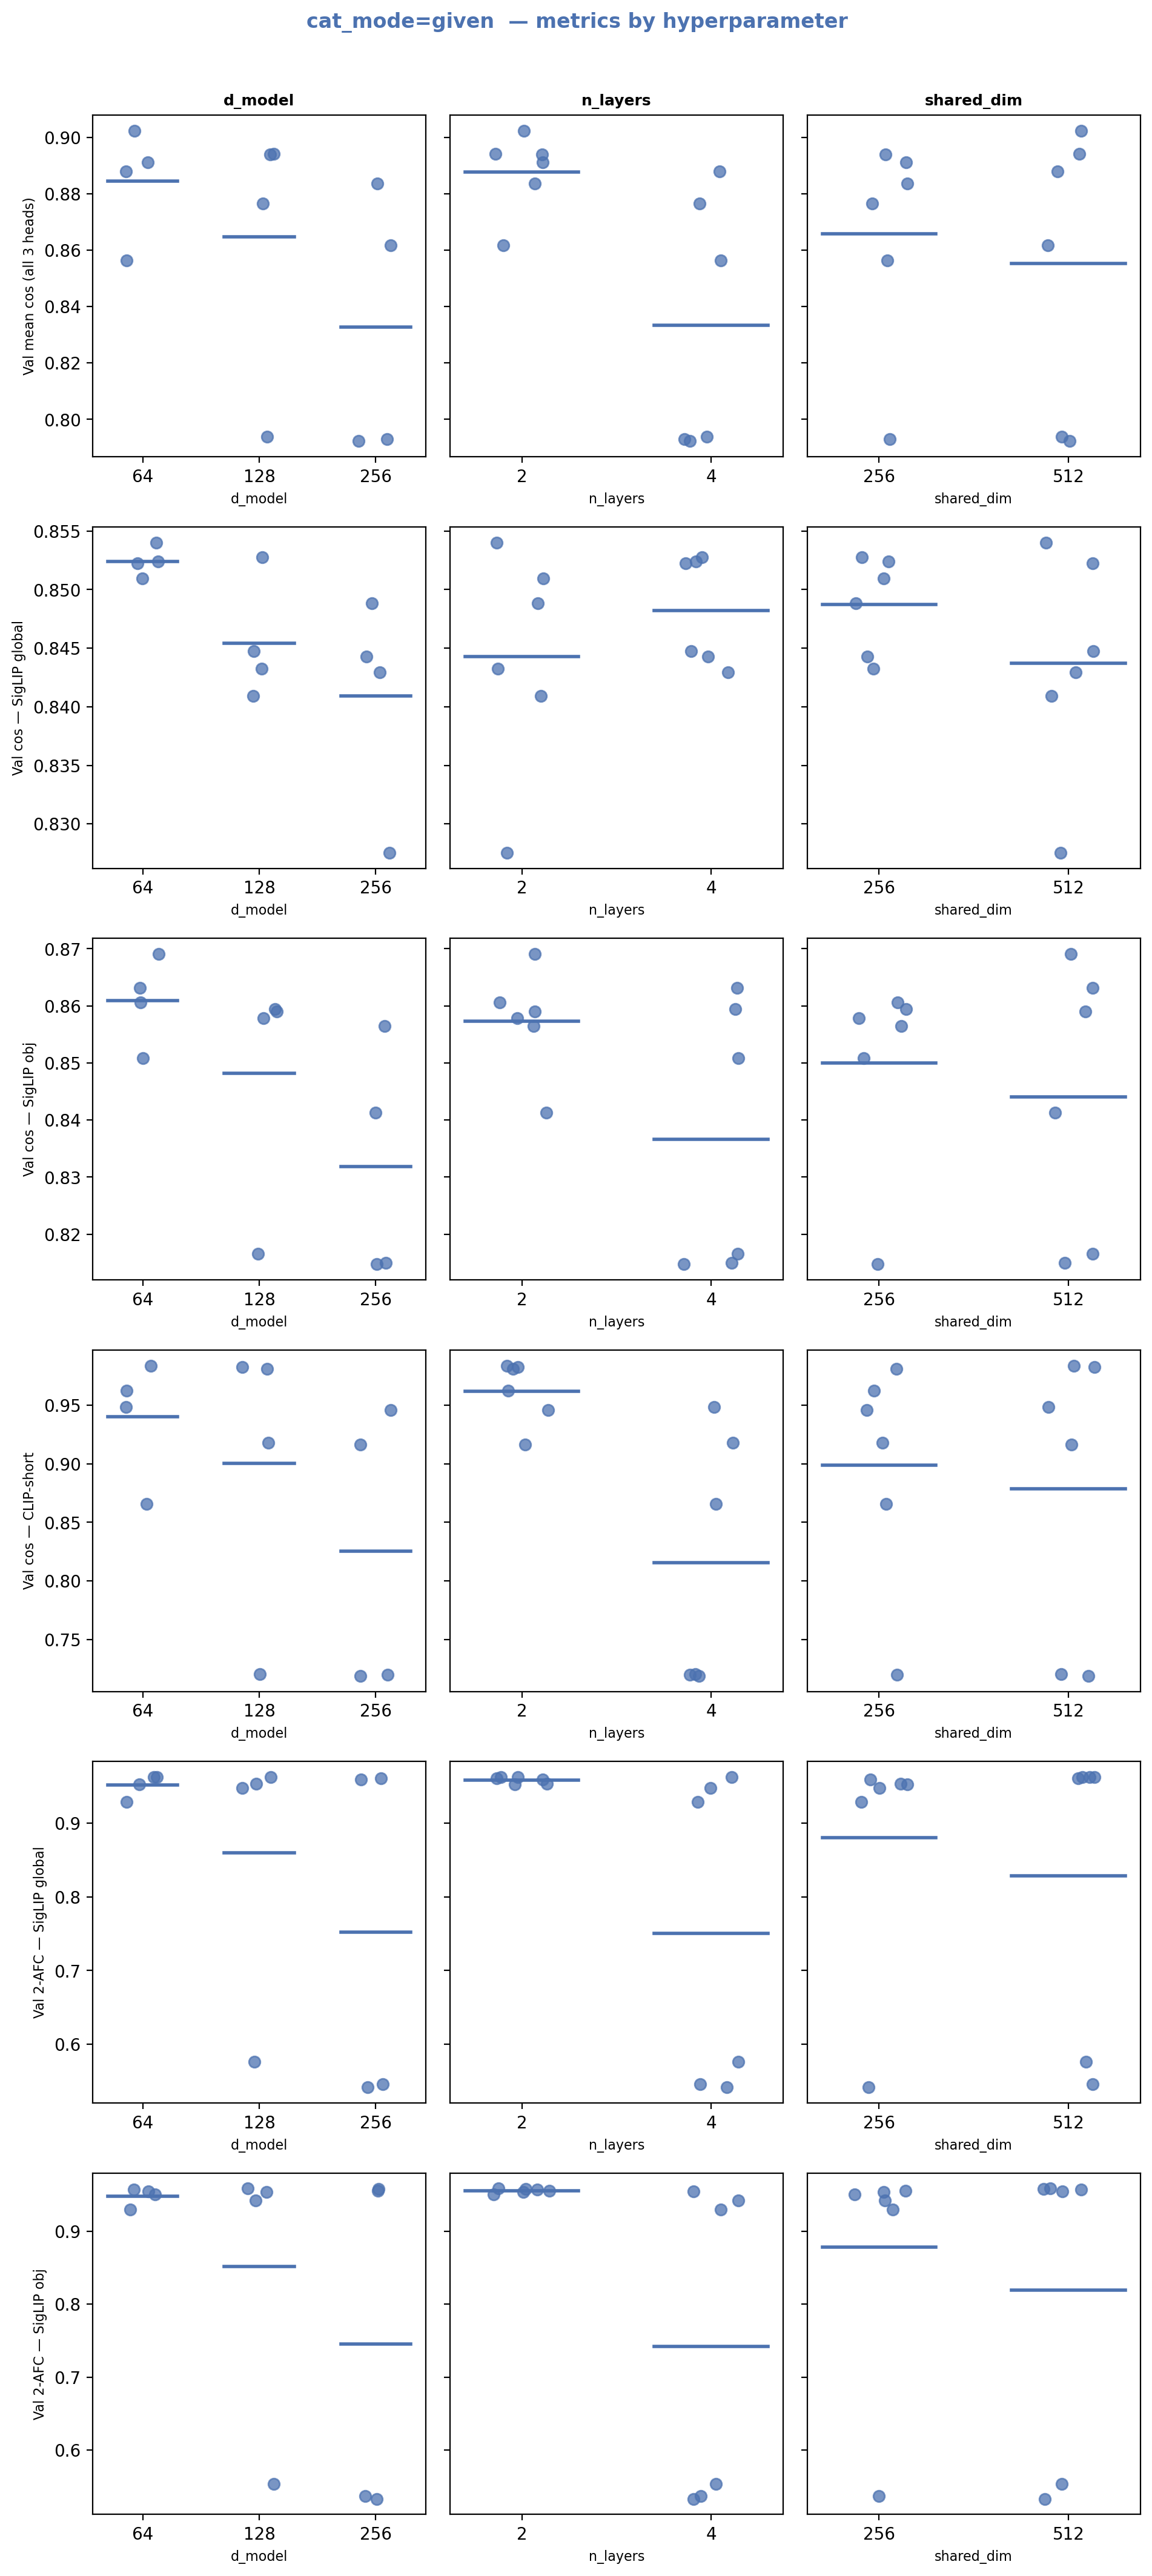

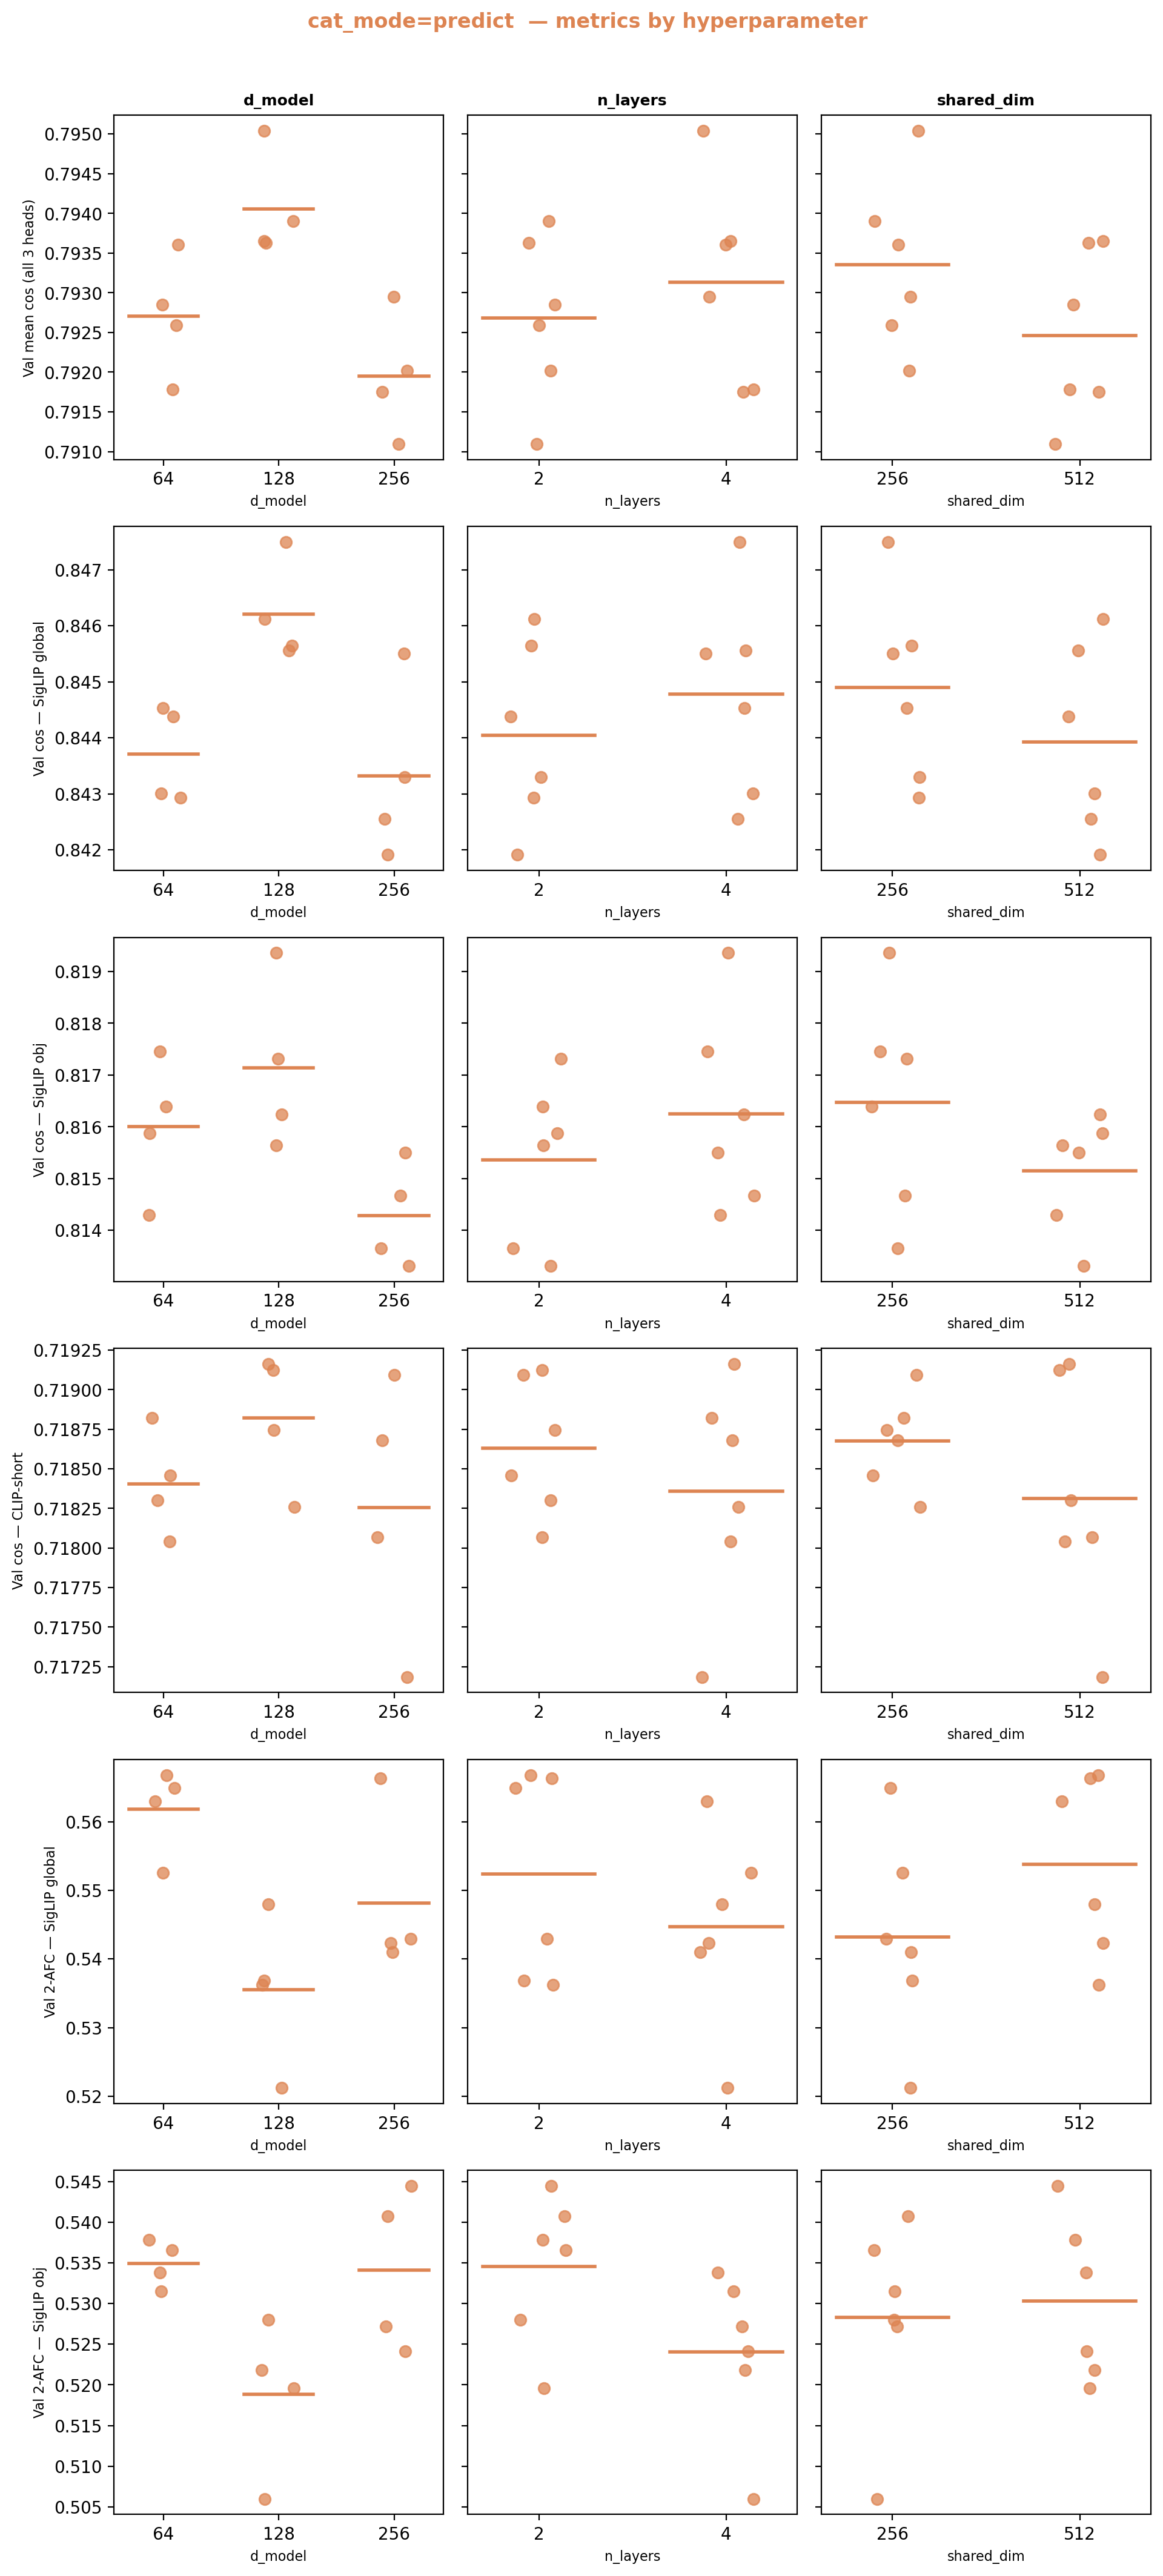

In [3]:
METRICS = [
    ('val_mean_cos',           'Val mean cos (all 3 heads)'),
    ('val_cos_siglip_global',  'Val cos — SigLIP global'),
    ('val_cos_siglip_obj',     'Val cos — SigLIP obj'),
    ('val_cos_clip',           'Val cos — CLIP-short'),
    ('val_2afc_siglip_global', 'Val 2-AFC — SigLIP global'),
    ('val_2afc_siglip_obj',    'Val 2-AFC — SigLIP obj'),
]
METRICS = [(m, l) for m, l in METRICS if m in df.columns]

NUMERIC_AXES = ['d_model', 'n_layers', 'shared_dim']
NUMERIC_AXES = [a for a in NUMERIC_AXES if a in df.columns]

modes = sorted(df['cat_mode'].unique())
mode_color = {'given': '#4C72B0', 'predict': '#DD8452'}

n_rows = len(METRICS)
n_axes = len(NUMERIC_AXES)
n_modes = len(modes)

rng = np.random.default_rng(0)

# One figure per cat_mode so sharey='row' applies within each mode only
for mode in modes:
    df_mode = df[df['cat_mode'] == mode]
    color = mode_color.get(mode, 'grey')

    fig, axes = plt.subplots(n_rows, n_axes,
                             figsize=(3.2 * n_axes, 3.5 * n_rows),
                             sharey='row', squeeze=False)

    for mi, (metric, ylabel) in enumerate(METRICS):
        for ai, axis_col in enumerate(NUMERIC_AXES):
            ax = axes[mi, ai]
            levels = sorted(df[axis_col].unique())
            for lvl_i, lvl in enumerate(levels):
                vals = df_mode[df_mode[axis_col] == lvl][metric].dropna().values
                if not len(vals): continue
                jitter = rng.uniform(-0.15, 0.15, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=color, alpha=0.75, s=45)
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [vals.mean(), vals.mean()], color=color, lw=2)
            ax.set_xticks(range(len(levels)))
            ax.set_xticklabels([str(l) for l in levels])
            ax.set_xlabel(axis_col, fontsize=8)
            if ai == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            if mi == 0:
                ax.set_title(axis_col, fontsize=9, fontweight='bold')

    fig.suptitle(f'cat_mode={mode}  — metrics by hyperparameter',
                 fontweight='bold', color=color, y=1.01)
    plt.tight_layout()
    plt.show()


## given vs predict: head-by-head comparison

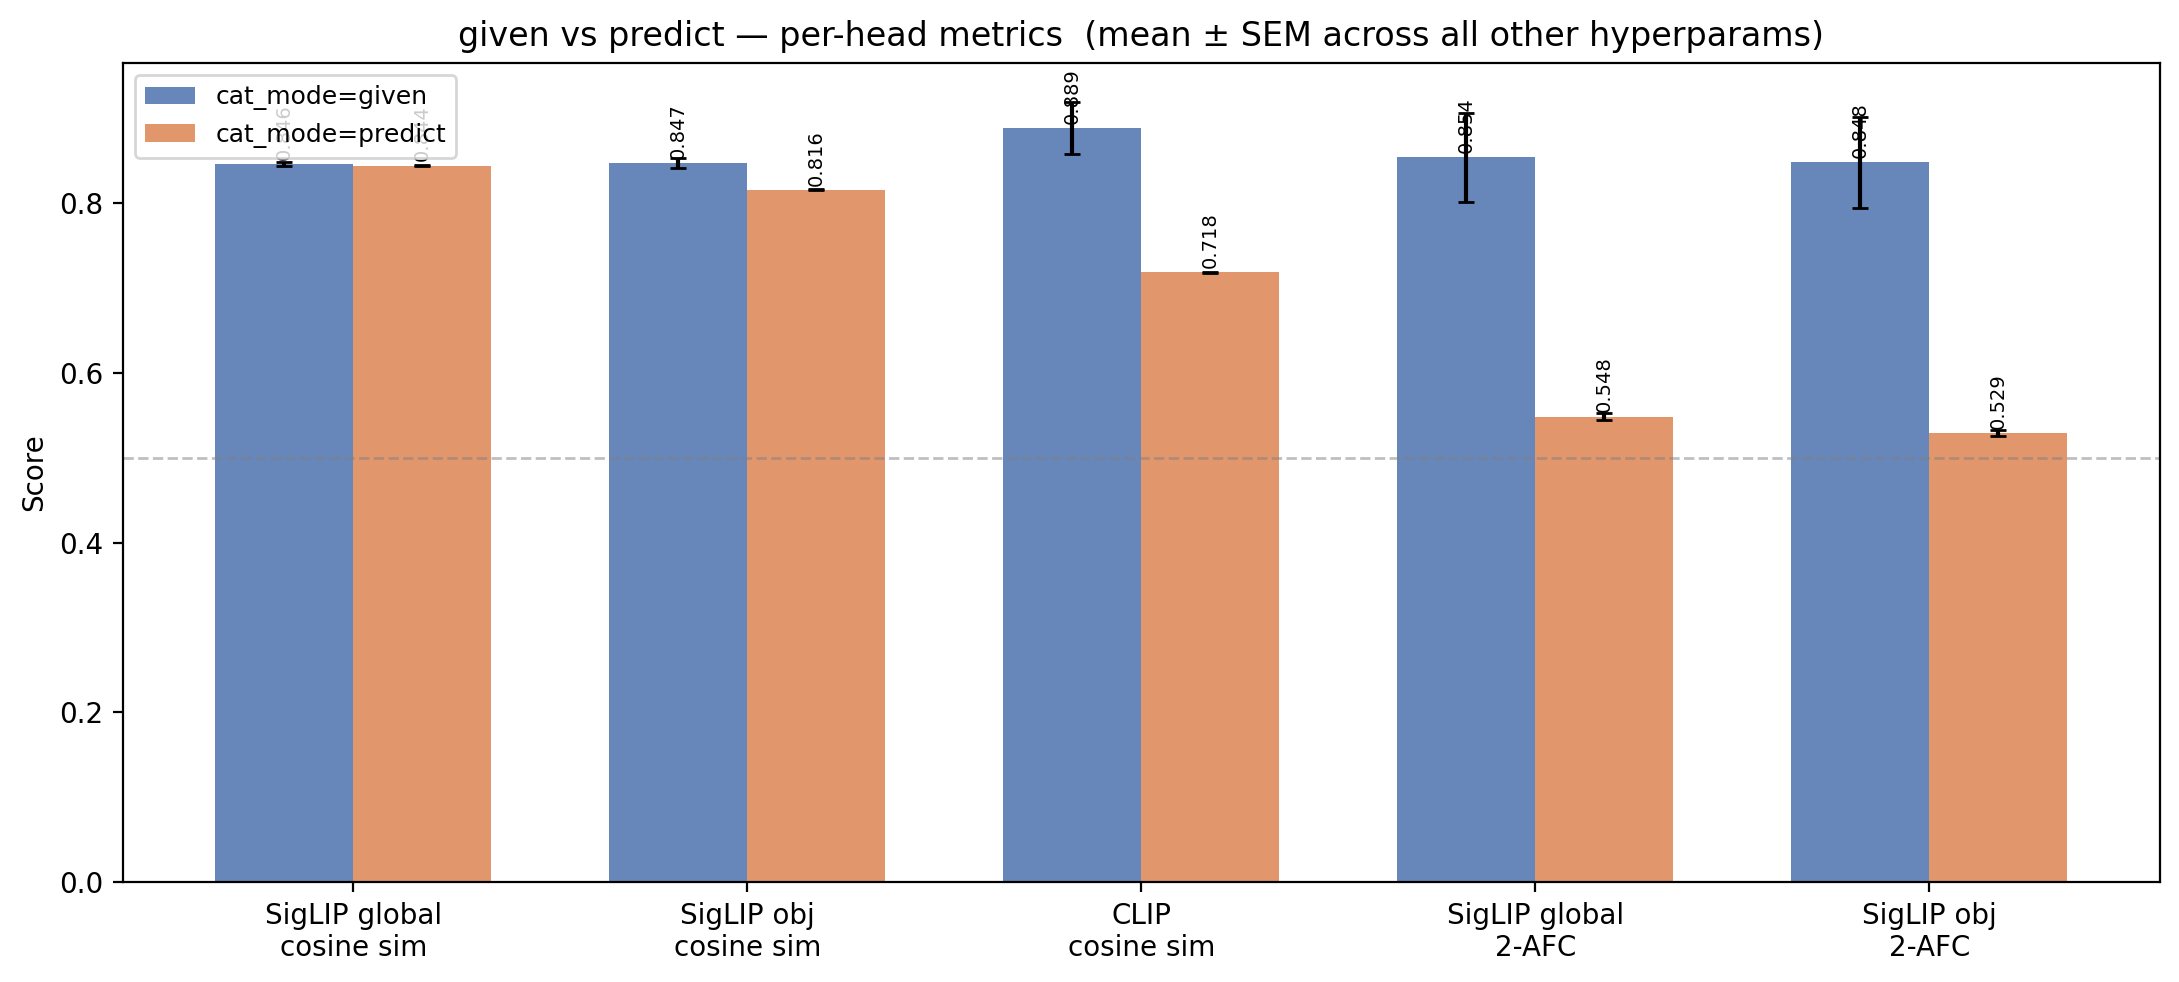


Category classification accuracy (predict mode only):


,mean,sem
cat_mode,,
given,NaN,NaN
predict,0.175926,0.008523


In [4]:
head_metrics = [
    ('val_cos_siglip_global',  'SigLIP global\ncosine sim'),
    ('val_cos_siglip_obj',     'SigLIP obj\ncosine sim'),
    ('val_cos_clip',           'CLIP\ncosine sim'),
    ('val_2afc_siglip_global', 'SigLIP global\n2-AFC'),
    ('val_2afc_siglip_obj',    'SigLIP obj\n2-AFC'),
]
head_metrics = [(m, l) for m, l in head_metrics if m in df.columns]

modes  = sorted(df['cat_mode'].unique())
x      = np.arange(len(head_metrics))
width  = 0.35
colors = {'given': '#4C72B0', 'predict': '#DD8452'}

fig, ax = plt.subplots(figsize=(11, 5))
for i, mode in enumerate(modes):
    sub   = df[df['cat_mode'] == mode]
    means = [sub[m].mean() for m, _ in head_metrics]
    sems  = [sub[m].sem()  for m, _ in head_metrics]
    offset = (i - (len(modes)-1)/2) * width
    bars = ax.bar(x + offset, means, width, yerr=sems, capsize=3,
                  label=f'cat_mode={mode}', color=colors.get(mode, f'C{i}'), alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([l for _, l in head_metrics])
ax.set_ylabel('Score')
ax.set_title('given vs predict — per-head metrics  (mean ± SEM across all other hyperparams)')
ax.legend(fontsize=9)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

if 'val_cat_acc' in df.columns:
    cat_acc = df.groupby('cat_mode')['val_cat_acc'].agg(['mean', 'sem'])
    print("\nCategory classification accuracy (predict mode only):")
    display(cat_acc)

## Effect of d_model

/tmp/ipykernel_7102/4131866492.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(dm_metrics))


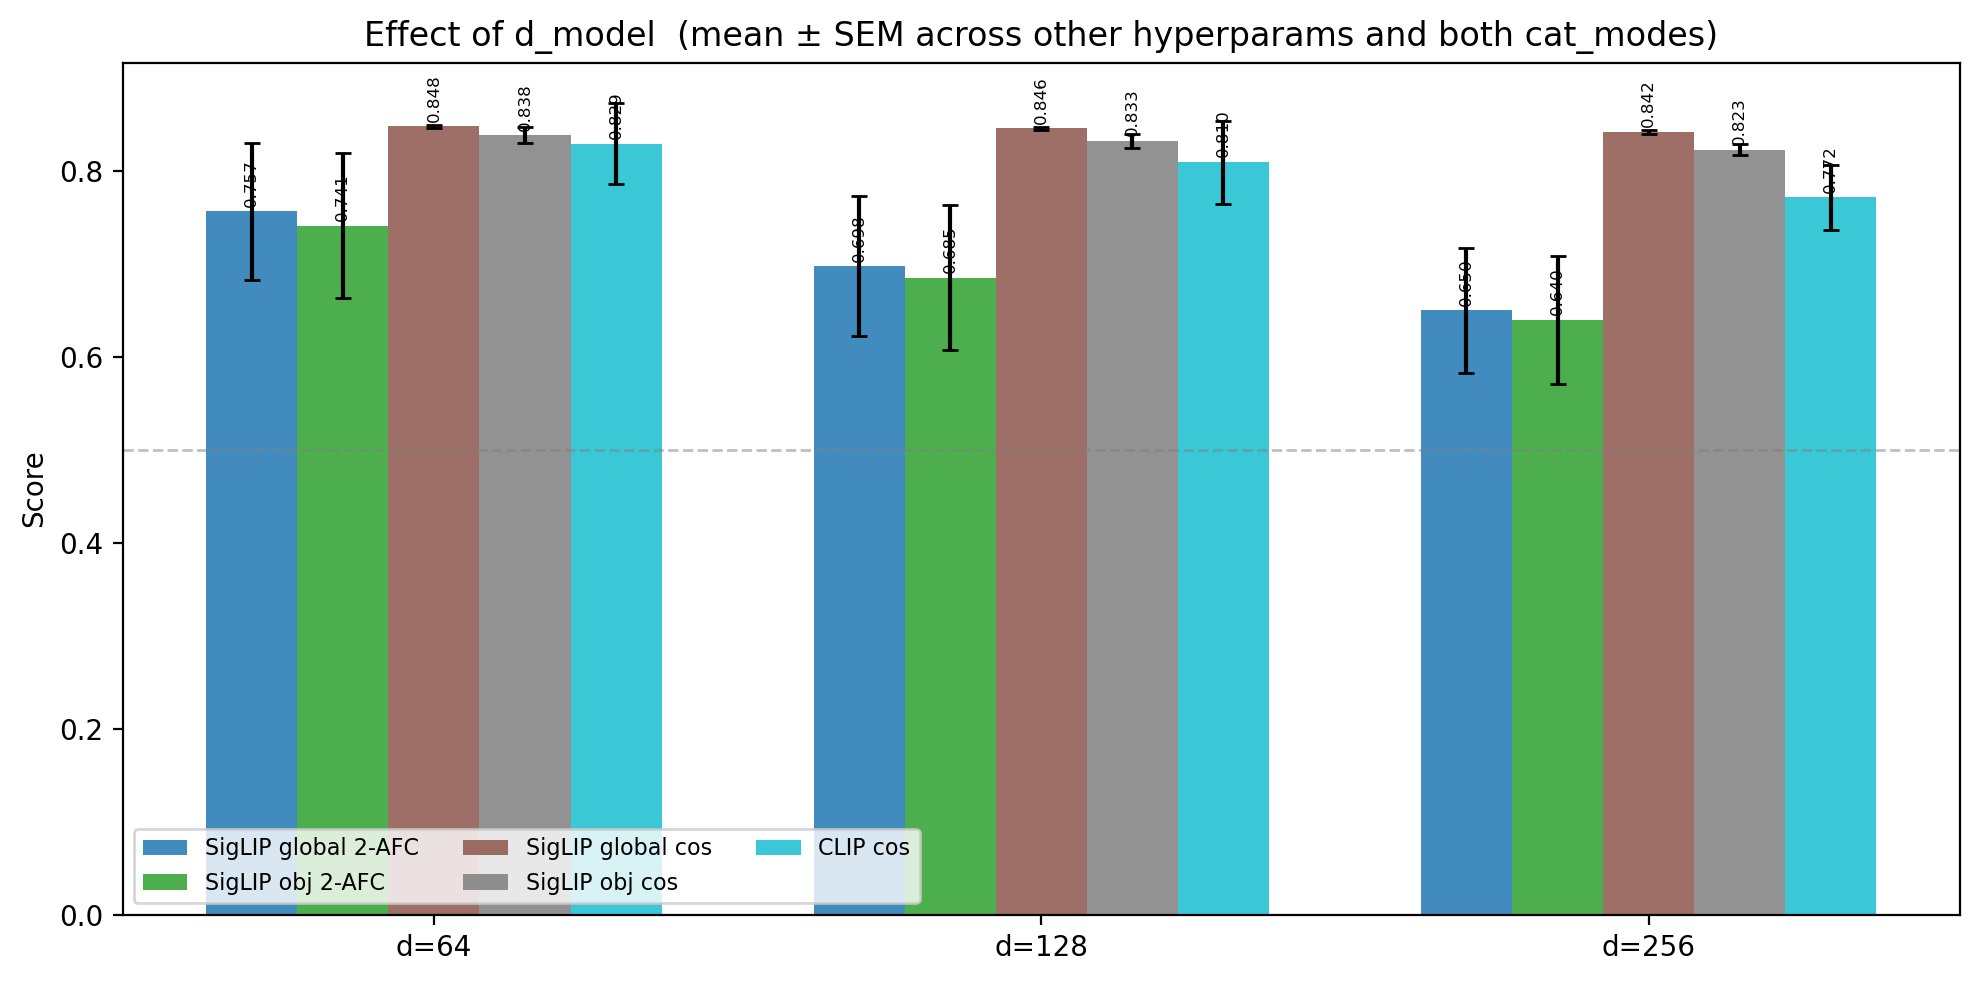

In [5]:
dm_metrics = [
    ('val_2afc_siglip_global', 'SigLIP global 2-AFC'),
    ('val_2afc_siglip_obj',    'SigLIP obj 2-AFC'),
    ('val_cos_siglip_global',  'SigLIP global cos'),
    ('val_cos_siglip_obj',     'SigLIP obj cos'),
    ('val_cos_clip',           'CLIP cos'),
]
dm_metrics = [(m, l) for m, l in dm_metrics if m in df.columns]

dm_labels = sorted(df['d_model'].unique())
x     = np.arange(len(dm_labels))
width = 0.15

cmap = plt.cm.get_cmap('tab10', len(dm_metrics))
fig, ax = plt.subplots(figsize=(10, 5))
offsets = np.linspace(-(len(dm_metrics)-1)/2, (len(dm_metrics)-1)/2, len(dm_metrics)) * width

for off, (metric, label), color in zip(offsets, dm_metrics, [cmap(i) for i in range(len(dm_metrics))]):
    means = [df[df['d_model'] == d][metric].mean() for d in dm_labels]
    sems  = [df[df['d_model'] == d][metric].sem()  for d in dm_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3,
                   label=label, color=color, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'd={d}' for d in dm_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of d_model  (mean ± SEM across other hyperparams and both cat_modes)')
ax.legend(fontsize=8, ncol=3)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Val vs test generalisation

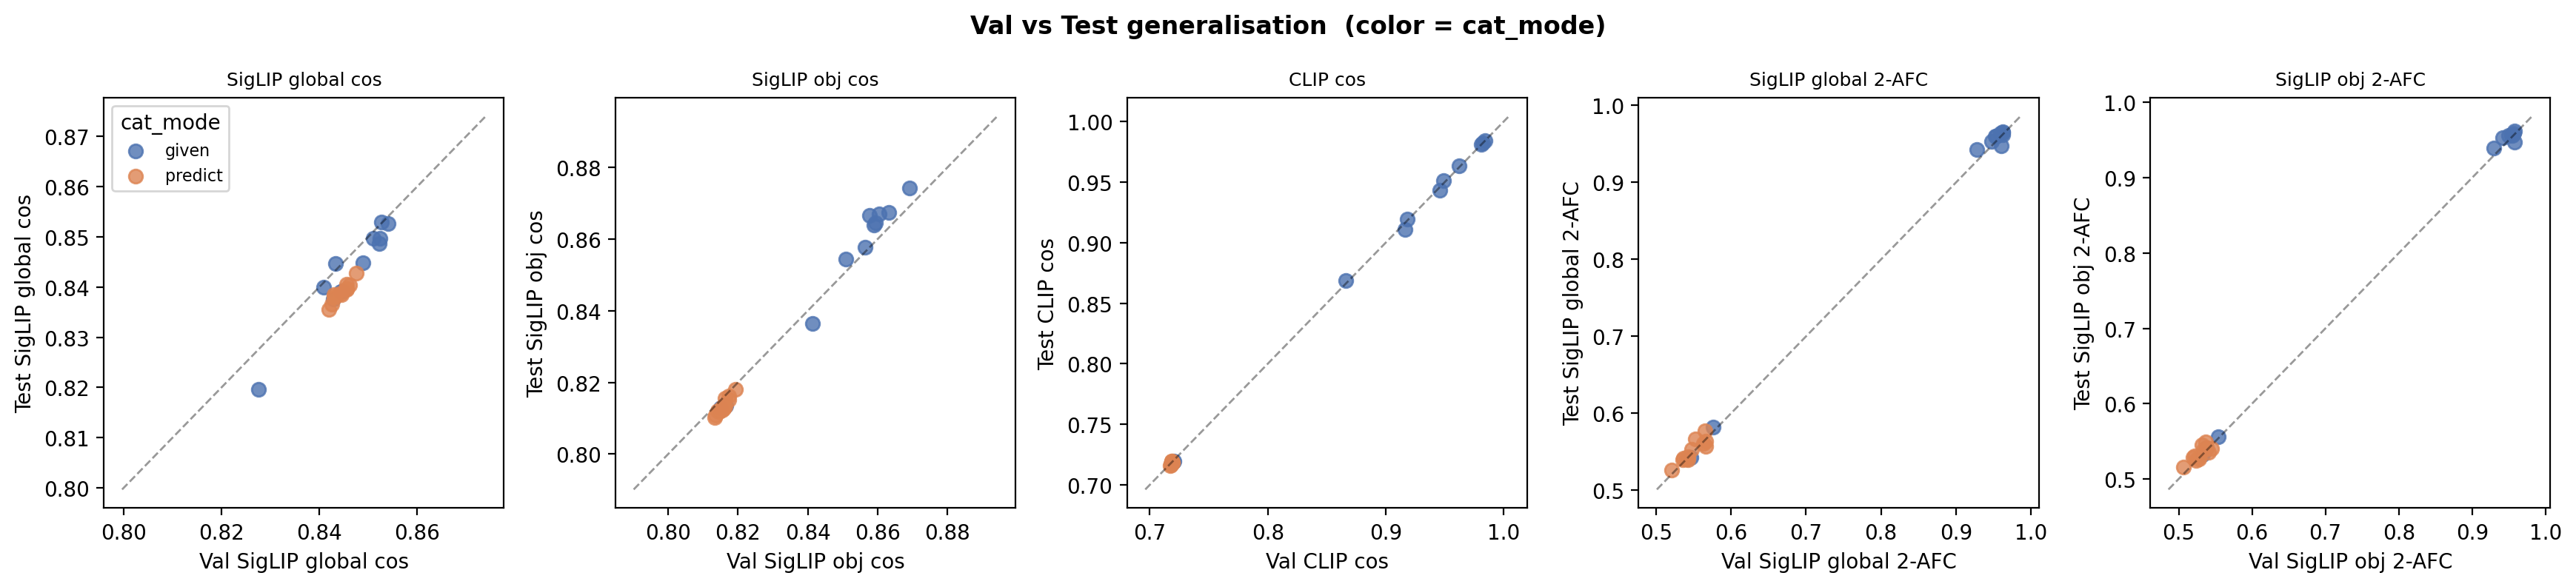

In [6]:
if has_test:
    pairs = [
        ('val_cos_siglip_global',  'test_cos_siglip_global',  'SigLIP global cos'),
        ('val_cos_siglip_obj',     'test_cos_siglip_obj',     'SigLIP obj cos'),
        ('val_cos_clip',           'test_cos_clip',           'CLIP cos'),
        ('val_2afc_siglip_global', 'test_2afc_siglip_global', 'SigLIP global 2-AFC'),
        ('val_2afc_siglip_obj',    'test_2afc_siglip_obj',    'SigLIP obj 2-AFC'),
    ]
    pairs = [(v, t, l) for v, t, l in pairs if v in df.columns and t in df.columns]
    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 4))
    mode_color = {'given': '#4C72B0', 'predict': '#DD8452'}
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        for mode, grp in df.dropna(subset=[vcol, tcol]).groupby('cat_mode'):
            ax.scatter(grp[vcol], grp[tcol],
                       color=mode_color.get(mode, 'grey'),
                       label=mode, s=45, alpha=0.8)
        lims = [min(df[vcol].min(), df[tcol].min()) - 0.02,
                max(df[vcol].max(), df[tcol].max()) + 0.02]
        ax.plot(lims, lims, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Val {title}')
        ax.set_ylabel(f'Test {title}')
        ax.set_title(title, fontsize=9)
    axes[0].legend(title='cat_mode', fontsize=8)
    fig.suptitle('Val vs Test generalisation  (color = cat_mode)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Test metrics not yet available — rerun once all jobs complete.')

## Top-10 runs by val mean cosine similarity

In [7]:
top_cols = [c for c in [
    'cat_mode', 'd_model', 'n_layers', 'shared_dim',
    'epoch', 'val_mean_cos', 'val_mean_2afc',
    'val_cos_siglip_global', 'val_cos_siglip_obj', 'val_cos_clip',
    'val_2afc_siglip_global', 'val_2afc_siglip_obj',
    'val_cat_acc',
    'test_cos_siglip_global', 'test_cos_siglip_obj', 'test_cos_clip',
    'test_2afc_siglip_global', 'test_2afc_siglip_obj',
    'test_cat_acc', 'path',
] if c in df.columns]
display(df.sort_values('val_mean_cos', ascending=False)[top_cols].head(10).reset_index(drop=True))

,cat_mode,d_model,n_layers,shared_dim,epoch,val_mean_cos,val_mean_2afc,val_cos_siglip_global,val_cos_siglip_obj,val_cos_clip,val_2afc_siglip_global,val_2afc_siglip_obj,val_cat_acc,test_cos_siglip_global,test_cos_siglip_obj,test_cos_clip,test_2afc_siglip_global,test_2afc_siglip_obj,test_cat_acc,path
0,given,64,2,512,144,0.902382,0.959551,0.854023,0.869082,0.984039,0.962297,0.956804,NaN,0.852560,0.874363,0.984504,0.964919,0.959551,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
1,given,128,2,512,138,0.894166,0.960300,0.840935,0.858983,0.982581,0.962297,0.958302,NaN,0.840007,0.863876,0.982309,0.966167,0.961923,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
2,given,128,2,256,153,0.894030,0.953371,0.843237,0.857811,0.981041,0.953059,0.953683,NaN,0.844690,0.866741,0.981295,0.960424,0.957678,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
3,given,64,2,256,181,0.891328,0.951186,0.850967,0.860549,0.962467,0.952310,0.950062,NaN,0.849741,0.867003,0.963175,0.959800,0.956180,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
4,given,64,4,512,194,0.888077,0.958614,0.852246,0.863176,0.948810,0.962297,0.954931,NaN,0.848673,0.867409,0.951168,0.961548,0.956305,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
5,given,256,2,256,161,0.883725,0.957179,0.848847,0.856424,0.945905,0.959176,0.955181,NaN,0.844760,0.857849,0.943379,0.963920,0.957678,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
6,given,128,4,256,191,0.876710,0.944694,0.852761,0.859433,0.917937,0.947441,0.941948,NaN,0.852963,0.864633,0.919397,0.953184,0.953059,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
7,given,256,2,512,165,0.861708,0.958989,0.827532,0.841309,0.916283,0.960549,0.957428,NaN,0.819678,0.836556,0.911061,0.947441,0.947441,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
8,given,64,4,256,200,0.856390,0.928777,0.852382,0.850879,0.865909,0.928215,0.929338,NaN,0.849633,0.854451,0.868660,0.943196,0.939700,NaN,/home/yy3658/NeurObjectGen/checkpoints/multihe...
9,predict,128,4,256,41,0.795038,0.513608,0.847496,0.819358,0.718259,0.521223,0.505993,0.133333,0.842710,0.817968,0.718422,0.526092,0.515605,0.155556,/home/yy3658/NeurObjectGen/checkpoints/multihe...


## Best config — all metrics summary bar chart

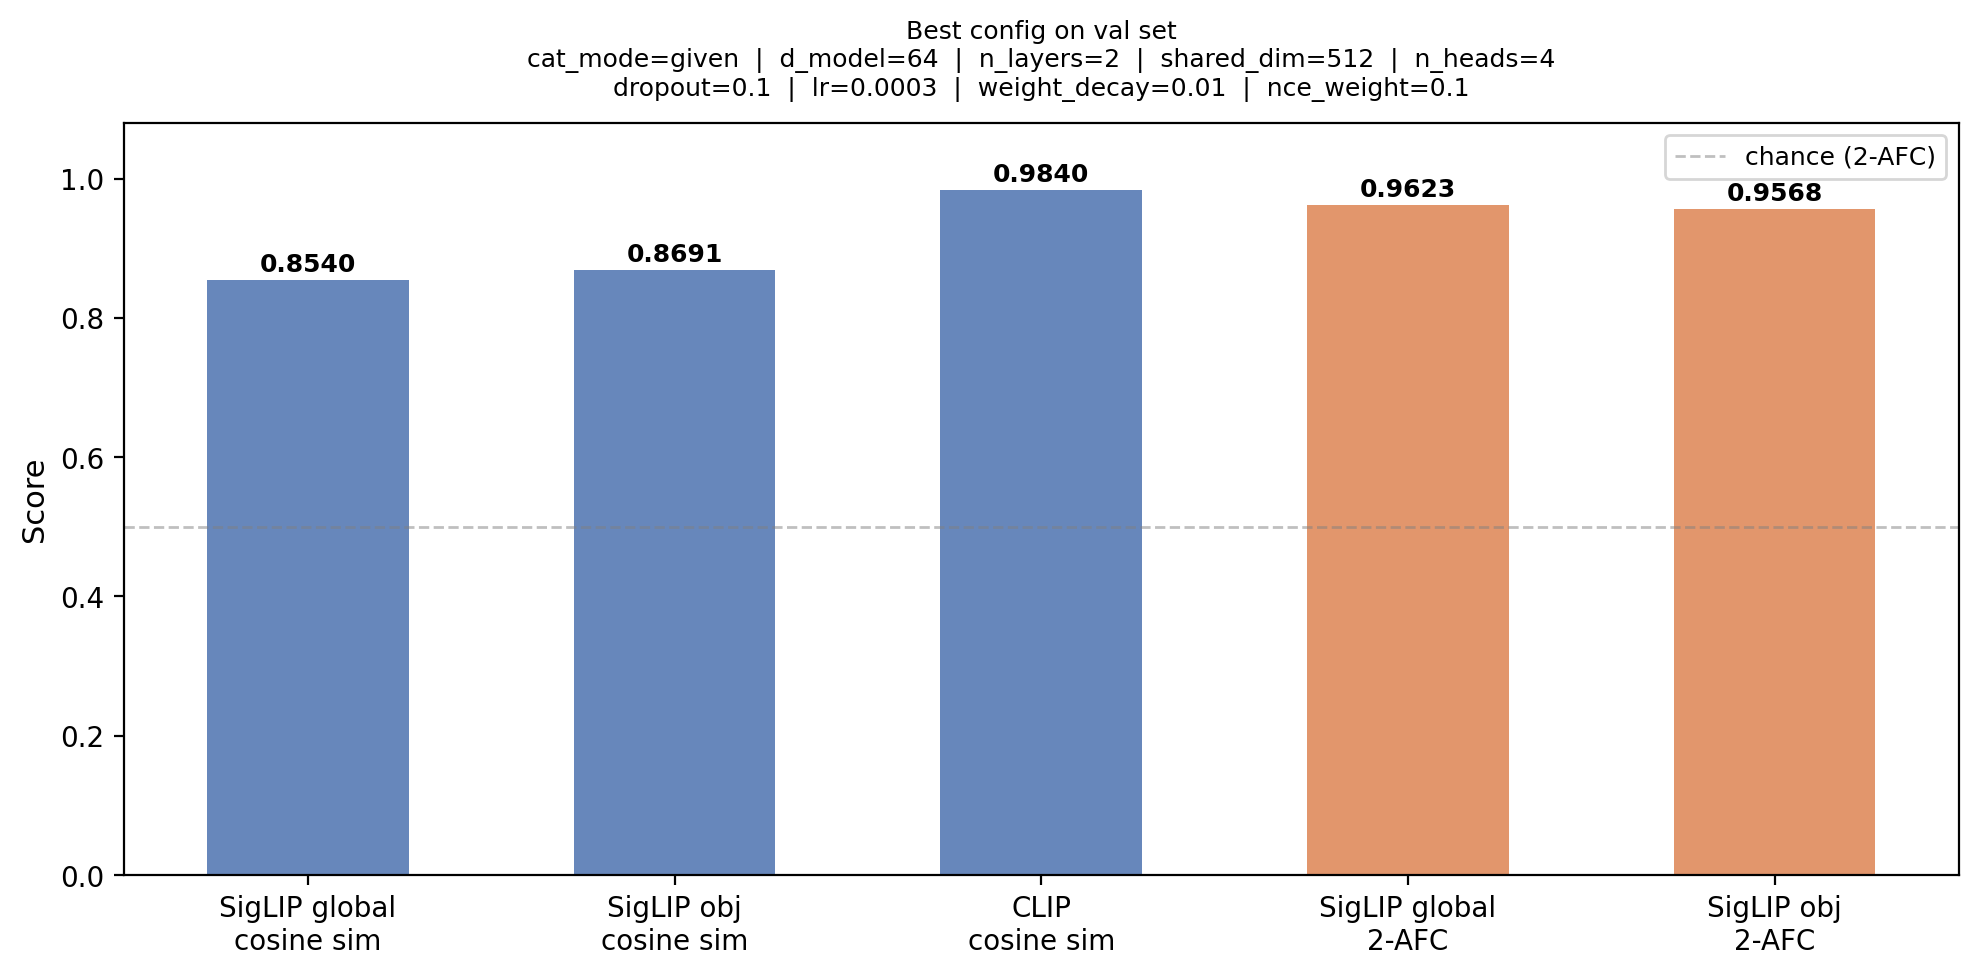

In [8]:
BEST_METRICS = [
    ('val_cos_siglip_global',  'SigLIP global\ncosine sim'),
    ('val_cos_siglip_obj',     'SigLIP obj\ncosine sim'),
    ('val_cos_clip',           'CLIP\ncosine sim'),
    ('val_2afc_siglip_global', 'SigLIP global\n2-AFC'),
    ('val_2afc_siglip_obj',    'SigLIP obj\n2-AFC'),
]
BEST_METRICS = [(m, l) for m, l in BEST_METRICS if m in df.columns]

best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]
vals     = [float(best_row[m]) for m, _ in BEST_METRICS]
labels   = [l for _, l in BEST_METRICS]
colors   = ['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.55)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5, label='chance (2-AFC)')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=9)

def _fmt(k, row):
    v = row[k]
    try:
        fv = float(v)
        return f'{k}={int(fv) if fv == int(fv) else fv:.4g}'
    except Exception:
        return f'{k}={v}'

hp_keys1 = ['cat_mode', 'd_model', 'n_layers', 'shared_dim', 'n_heads']
hp_keys2 = ['dropout', 'lr', 'weight_decay', 'nce_weight']
hp_line1 = '  |  '.join(_fmt(k, best_row) for k in hp_keys1 if k in best_row)
hp_line2 = '  |  '.join(_fmt(k, best_row) for k in hp_keys2 if k in best_row)
if 'val_cat_acc' in best_row and not np.isnan(float(best_row['val_cat_acc'])):
    hp_line2 += f'  |  cat_acc={float(best_row["val_cat_acc"]):.3f}'
ax.set_title(f'Best config on val set\n{hp_line1}\n{hp_line2}', fontsize=9, pad=10)
plt.tight_layout()
plt.show()

In [9]:
import json
from config_const import CACHE_DIR

CACHE_DIR.mkdir(parents=True, exist_ok=True)

for mode in sorted(df['cat_mode'].unique()):
    df_mode = df[df['cat_mode'] == mode]
    if df_mode.empty:
        continue
    best_row = df_mode.sort_values('val_mean_cos', ascending=False).iloc[0]
    config = {
        'model':      'multihead_v2',
        'dataset':    'hvm',
        'cat_mode':   mode,
        'val_mean_cos':  float(best_row['val_mean_cos']),
        'val_mean_2afc': float(best_row.get('val_mean_2afc', float('nan'))),
        'checkpoint': best_row['path'],
        'd_model':    int(best_row['d_model']),
        'n_heads':    int(best_row['n_heads']),
        'n_layers':   int(best_row['n_layers']),
        'shared_dim': int(best_row['shared_dim']),
        'dropout':    float(best_row['dropout']),
        'lr':         float(best_row['lr']),
        'weight_decay':           float(best_row['weight_decay']),
        'nce_weight':             float(best_row['nce_weight']),
        'loss_weight_siglip':     float(best_row['loss_weight_siglip']),
        'loss_weight_siglip_obj': float(best_row['loss_weight_siglip_obj']),
        'loss_weight_clip':       float(best_row['loss_weight_clip']),
    }
    out_path = CACHE_DIR / f'best_hvm_multihead_v2_{mode}_config.json'
    with open(out_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f'Saved {mode} -> {out_path}')
    print(f"  val_mean_cos={config['val_mean_cos']:.4f}  d_model={config['d_model']}  n_layers={config['n_layers']}  shared_dim={config['shared_dim']}")
    print(f"  {config['checkpoint']}")
    print()


Saved given -> /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_v2_given_config.json
  val_mean_cos=0.9024  d_model=64  n_layers=2  shared_dim=512
  /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmgiven/best.pt

Saved predict -> /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_v2_predict_config.json
  val_mean_cos=0.7950  d_model=128  n_layers=4  shared_dim=256
  /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2/d128_nh4_nl4_sd256_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmpredict/best.pt



## Per-category cosine similarity — all three heads (test set)
Loads the best checkpoint and runs inference on the 90 held-out test stimuli.

In [ ]:
import torch
import torch.nn.functional as F
from config_const import (
    HVM_CATEGORIES, HVM_N_VAR, HVM_N_STIMULI,
    HVM_SIGLIP_EMBEDDINGS_PATH, HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, HVM_CLIP_EMBEDS_PATH,
)
from data_utils.hvm_loader import _load_hvm_neural, _category_stratified_split
from encoders import MultiHeadTransformerV2

best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]

# ── load data
rsp, _, _ = _load_hvm_neural()
neural_t     = torch.from_numpy(rsp).float()
siglip_t     = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH,     weights_only=True)
siglip_obj_t = F.normalize(torch.load(HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, weights_only=True), dim=-1)
clip_t       = F.normalize(torch.load(HVM_CLIP_EMBEDS_PATH, weights_only=True), dim=-1)
cat_indices  = torch.arange(HVM_N_STIMULI) // HVM_N_VAR

_, _, test_idx_np = _category_stratified_split(seed=0)
test_idx    = torch.from_numpy(test_idx_np).long()
neural_test = neural_t[test_idx].permute(0, 2, 1)   # (90, T, N)
gt_sg       = siglip_t[test_idx]
gt_so       = siglip_obj_t[test_idx]
gt_clip     = clip_t[test_idx]
test_cats   = cat_indices[test_idx]

# ── build & load model
m = MultiHeadTransformerV2(
    n_neurons=neural_t.shape[1],
    d_model=int(best_row['d_model']),
    n_heads=int(best_row['n_heads']),
    n_layers=int(best_row['n_layers']),
    shared_dim=int(best_row['shared_dim']),
    dropout=float(best_row['dropout']),
    n_categories=10,
)
ckpt = torch.load(best_row['path'], weights_only=False, map_location='cpu')
m.load_state_dict(ckpt['model_state'])
m.eval()

cat_mode = str(best_row.get('cat_mode', 'given'))
with torch.no_grad():
    pred = m(neural_test, test_cats, cat_mode=cat_mode)

pred_sg   = pred['siglip_global']
pred_so   = pred['siglip_obj']
pred_clip = pred['clip']

def per_cat(pred_t, gt_t):
    cos = F.cosine_similarity(pred_t, gt_t, dim=-1)
    means = [cos[test_cats == i].mean().item() for i in range(len(HVM_CATEGORIES))]
    sems  = [(cos[test_cats == i].std() /
              (test_cats == i).sum().float().sqrt()).item()
             for i in range(len(HVM_CATEGORIES))]
    return cos.mean().item(), means, sems

ov_sg,   m_sg,   s_sg   = per_cat(pred_sg,   gt_sg)
ov_so,   m_so,   s_so   = per_cat(pred_so,   gt_so)
ov_clip, m_clip, s_clip = per_cat(pred_clip, gt_clip)

x = np.arange(len(HVM_CATEGORIES))
width = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
for i, (m_vals, s_vals, label, color, ov) in enumerate([
    (m_sg,   s_sg,   'SigLIP global', '#4C72B0', ov_sg),
    (m_so,   s_so,   'SigLIP obj',    '#55A868', ov_so),
    (m_clip, s_clip, 'CLIP',          '#DD8452', ov_clip),
]):
    offset = (i - 1) * width
    ax.bar(x + offset, m_vals, width, yerr=s_vals, capsize=3,
           label=f'{label} (mean={ov:.3f})', color=color, alpha=0.85,
           error_kw=dict(lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(HVM_CATEGORIES)
ax.set_ylabel('Cosine similarity')
ax.set_title(f'Per-category cosine sim — all 3 heads — test set  (cat_mode={cat_mode})')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

Loading HVM sessions: 100%|██████████| 10/10 [00:39<00:00,  3.99s/it]


## Per-category classification accuracy (predict mode)
Only populated when the best run used `cat_mode=predict`.

In [ ]:
if cat_mode == 'predict' and pred['cat_logits'] is not None:
    cat_preds = pred['cat_logits'].argmax(-1)
    correct   = (cat_preds == test_cats).float()
    per_cat_acc = [correct[test_cats == i].mean().item() for i in range(len(HVM_CATEGORIES))]
    overall_acc = correct.mean().item()

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(HVM_CATEGORIES, per_cat_acc, color='#8172B2', alpha=0.85, width=0.55)
    for bar, v in zip(bars, per_cat_acc):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(overall_acc, color='crimson', lw=1.5, ls='--',
               label=f'overall acc={overall_acc:.3f}')
    ax.axhline(0.1, color='grey', lw=1, ls=':', alpha=0.5, label='chance (0.10)')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Classification accuracy')
    ax.set_title('Per-category classification accuracy — test set (predict mode)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Cat classification accuracy only available for cat_mode=predict.')